In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.ticker as mticker
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import json
import os
from utils import OUT_PATH, FREQ_BAND, ExcludSubj, cleandfdecodingTS, EVENT_ID

from scipy.stats import spearmanr

tfr_path = OUT_PATH + '/Data_longWOBS'
event= list(EVENT_ID.keys())[:2]
color_ev = {0 : 'r', 1 : 'b'}
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('_TFRtrials.p'):] == '_TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_epoch = d['time_epoch']
    time_tfr=d['time_tfr']



col_pc = {0:"#0072B2", 1:"#D55E00", 2:"#009E73", 4:"#009E73"}
colors = plt.get_cmap('tab10')

element_colors = {elem: colors(i % 10) for i, elem in enumerate(FREQ_BAND)}



In [2]:
models = {
    'broadband0': ('mean', 'RandomForest'), 'broadband1': ('mean', 'LR'), "broadband2": ('mean', 'RandomForest'),
    'theta0': ('mean', 'SVC_linear'), 'theta1':( 'mean', 'LR'), "theta2" : ('mean', 'LR'),
    'alpha0': ('mean', 'LR'), 'alpha1':( 'mean', 'LR'), "alpha2" : ( 'mean', 'LR'),
    'low_beta0': ('mean', 'LR'), 'low_beta1':( 'mean', 'LR'), "low_beta2" : ( 'mean', 'LR'),
    'high_beta0': ('mean', 'LR'), 'high_beta1':( 'duplicat', 'LR'), "high_beta2" : ( 'mean', 'LR'),
    'high_gamma0': ('mean', 'RandomForest'), 'high_gamma1':( 'mean', 'LR'), "high_gamma2" : ( 'mean', 'RandomForest') }


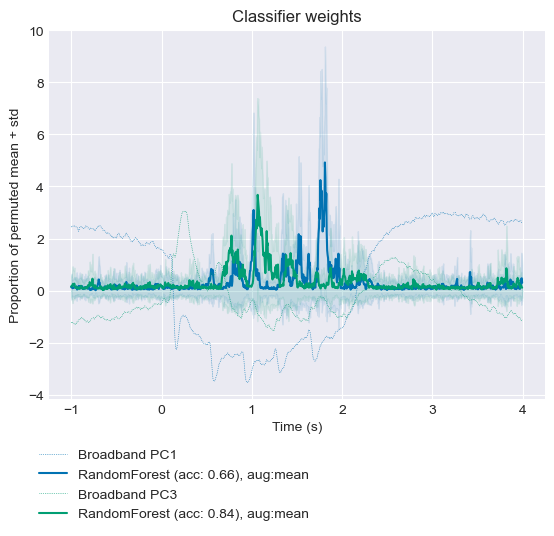

In [3]:

signals = [('broadband', 'mean', 0), ('broadband', 'mean',2)]
time = time_epoch
time_lenght = len(time)

for band, method_pca, pc_use in signals :
    ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

    for col in ['expl_var', 'compo', 'freq', 'subj'] : 
        if col in ts.columns : 
            ts = ts.drop(columns = col)

    ts = ts.to_numpy()
    ts_pc=np.concat([ts[None, pc_use, :int(ts.shape[1]/2)], ts[None, pc_use, int(ts.shape[1]/2):]], axis = 0)
    
    data_aug_method = models[band + str(pc_use)][0]
    model = models[band + str(pc_use)][1]
    df_final = pd.read_csv(OUT_PATH + f'/Decoding/{band}/fullmodel/{method_pca}_{data_aug_method}_{pc_use}_{model}full.csv')
    result = cleandfdecodingTS(df_final, time_lenght)
    
    if result['acc'] < 0.6 :
        continue

    label_plot = f'{model.replace("_", " ")} (acc: {np.round(result["acc"], 2)}), aug:{data_aug_method}'
    weight= abs(result['weight'])
    weight_mean_std = abs(result['weight_std'])
    weight_sh_mean= abs(result['weight_sh_mean'])
    weight_sh_std= abs(result['weight_sh_std'])
    weight_prop = weight/(weight_sh_mean+weight_sh_std)

    weight_prop_std = np.std(weight_prop, axis=0)
    weight_prop_mean= np.mean(weight_prop, axis=0)

    plt.plot(time, ts_pc[0, :]*350, ls = ':', c=col_pc[pc_use], linewidth = 0.5, label = band.capitalize().replace('_', ' ') + ' PC' + str(pc_use+1))
    plt.plot(time, weight_prop_mean, label = label_plot, c=col_pc[pc_use])
    plt.fill_between(time, weight_prop_mean - weight_prop_std, weight_prop_mean + weight_prop_std , alpha = 0.1,  color=col_pc[pc_use])
plt.grid()
plt.xlabel('Time (s)')
plt.title('Classifier weights')
plt.ylabel('Proportion of permuted mean + std')
plt.legend(bbox_to_anchor=(0.55, -0.1))
plt.show()


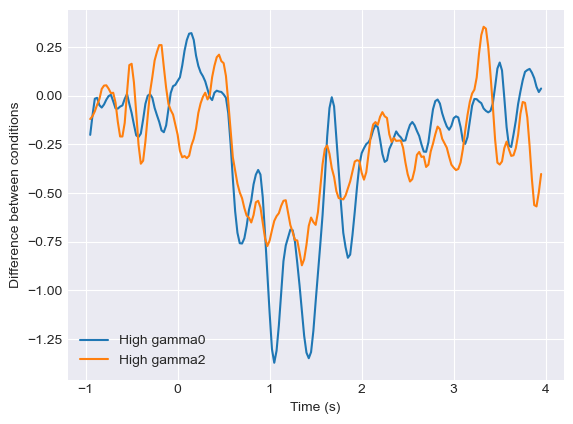

In [19]:
signals = [('high_gamma', 'concat', 0), ('high_gamma', 'concat', 2)]

label_plt = ''

for band, method_pca, pc in signals :
    # Get data
    ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')
    for col in ['expl_var', 'compo', 'freq', 'subj'] : 
        if col in ts.columns : 
            ts = ts.drop(columns = col)
 
    ts = ts.values
    ts_pc=np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis = 0)

    if band == 'alpha' :  # flip alpha
        ts_pc[:, 1, :] = - ts_pc[:, 1,:]


    # PLOT TS
    plt.plot(time_tfr, ts_pc[0, pc, :].T - ts_pc[1, pc, :].T, label = band.capitalize().replace('_', ' ') + str(pc))
plt.xlabel('Time (s)')
plt.ylabel('Difference between conditions')
plt.legend()
plt.grid()


In [11]:
from scipy.signal import find_peaks

def computeLagPeak(data_condi, time, win_high, method_pca, pc1=0, pc2=1, show=True, save=False, out_path =OUT_PATH, dis=60, diff=True) : 
    peaks_coni1 = {c:[] for c in [pc1, pc2]}
    if diff: 
        fig, ax = plt.subplots(3, 1, figsize=(12, 9))
        fig.suptitle(f'Peaks detection on PC1 and 2 time series -- {method_pca} PCA')
    lag_peak_time = []
    c=["#0072B2", "#D55E00", "#009E73"]

    for ie, i in enumerate([pc1, pc2]) : 
        for win, high in win_high[i]:
            coni = data_condi[i]
            peaks, _ = find_peaks(coni[win[0]:win[1]], height=high, distance=dis)
            peaks_coni1[i].extend([p + win[0] for p in peaks])

        if diff:
            if i == pc2 : 
                mul = -1
            else : 
                mul = 1
            ax[ie].plot(mul*coni, c=c[i], label=f'PC {i+1} Time series')
            for p in peaks_coni1[i] :
                ax[ie].scatter(p, mul*coni[p], color='red', label='Detected Peaks')
            ax[ie].set_title(f'PC {i+1}')
            ax[ie].grid()

    for j in range(len(peaks_coni1[0])) :
        if diff == True : 
            lag_peak_time.append(time[np.array(peaks_coni1[pc1][j])]- time[np.array(peaks_coni1[pc2][j])])
        if diff == False : 
            lag_peak_time.append((time[np.array(peaks_coni1[pc1][j])], time[np.array(peaks_coni1[pc2][j])]))
    
    mean_lag = np.mean(lag_peak_time)
    std_lag = np.std(lag_peak_time)

    if diff :
        ax[2].plot(time, data_condi[pc1], label='PC'+str(pc1+1), c=c[pc1])
        ax[2].plot(time + mean_lag, - data_condi[pc2], label='PC' +str(pc2+1), c=c[pc2])
        ax[2].set_title('PC2 shifted by mean lag')
        ax[2].set_xlabel('Time (s)')
        ax[2].legend()
        ax[2].grid()
        #ax[2].text(s=f'Mean lag : {np.round(mean_lag, 3)}s ± {np.round(std_lag, 3)}s', x=-0.5, y=-4)
        if show :
            plt.show()
        if save :
            fig.savefig(out_path + f'/lagPeak_{method_pca}.png')

    return lag_peak_time

In [25]:
# Broadband condi 
if condi == 'new' :
    win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
    1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}
elif condi == 'old' :
    win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
    1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}

if condi == 'new' :
        win_high = {0 : [([25, 125], 3)], 
        1: [([200, 230], 0), ([300, 550], -0.005)], 2 : [([25, 125], -1)]}
    elif condi == 'old' :
        win_high = {0 :  [([25, 125], 3)], 
        1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([25, 125], -1)]}


IndentationError: unindent does not match any outer indentation level (<string>, line 12)

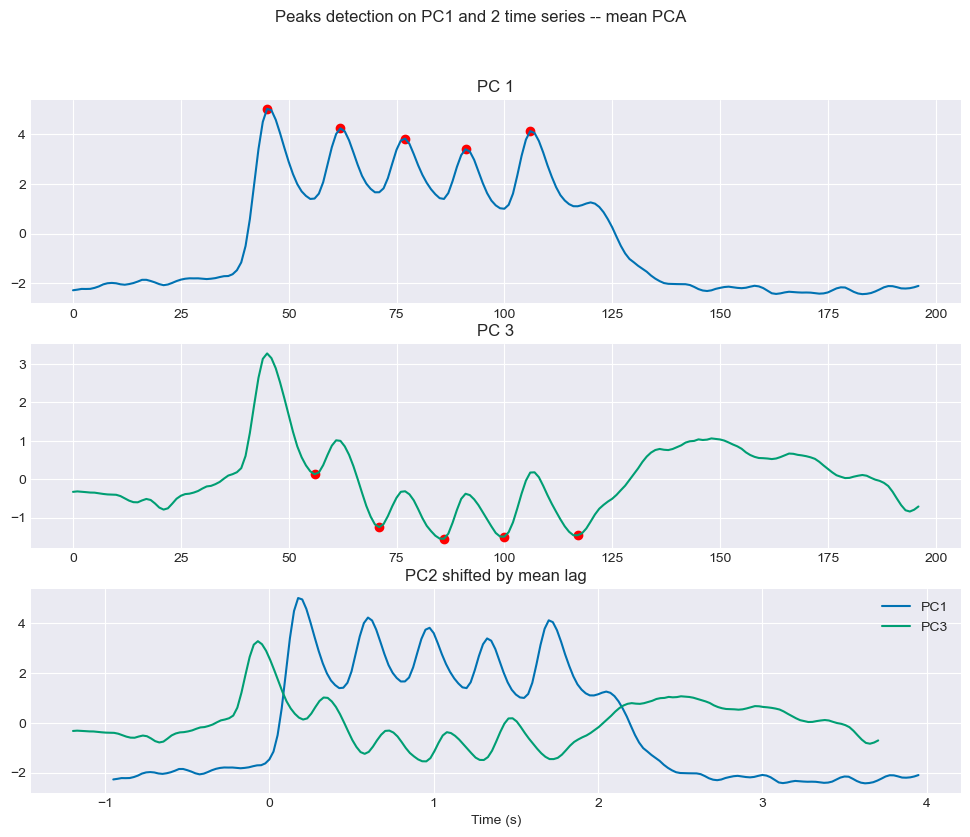

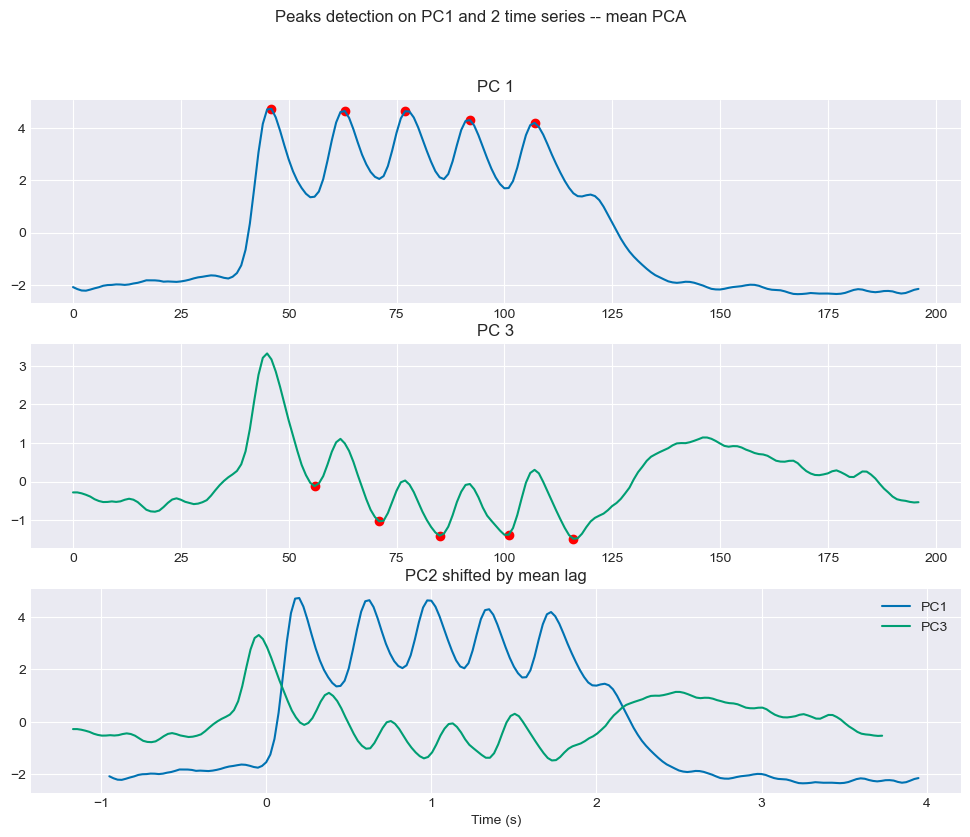

In [14]:
lag_dict={'mean_old':[], 'mean_new':[], 'concat_old':[], 'concat_new':[]}
pca_method = 'mean'
band = 'high_gamma'
data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{pca_method}/grp_{pca_method}_Xtrans_PCA5.csv').query('freq == @band').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj']).values #, 'expl_var']).values
data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)
data[:, 2, :] = -data[:, 2, :]
#data[:, 0, :] = -data[:,0, :]

for i_condi, condi in enumerate(['old', 'new']) : 
    coni = pd.DataFrame(data[i_condi, :,:].T).T

    if condi == 'new' :
        win_high = {0 : [([25, 125], 3)], 
        1: [([200, 230], 0), ([300, 550], -0.005)], 2 : [([40, 125], -1)]}
    elif condi == 'old' :
        win_high = {0 :  [([25, 125], 3)], 
        1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([25, 125], -1)]}

    lag = computeLagPeak(coni.values, time_tfr, win_high, method_pca=pca_method, show=True, dis=10, pc1=0, pc2=2, diff=True)
    lag_dict[f'{pca_method}_{condi}'].extend(lag)


In [20]:
np.std(lag_dict['mean_new'])

np.float64(0.018708286933869712)

In [174]:
lag_dict={'mean_old': [], 'mean_new': [], 'concat_old':[], 'concat_new':[]}

for pca_method in ['mean'] : #, 'concat'] :
    data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{pca_method}/grp_Xtrans_PCA5.csv').query('freq == "broadband"').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj']).values #, 'expl_var']).values
    data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)
    data[:, 1, :] = -data[:, 1, :]
    data[:, 0, :] = -data[:,0, :]

    for i_condi, condi in enumerate(['old', 'new']) : 
        coni = pd.DataFrame(data[i_condi, :,:].T).T

        if condi == 'new' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}
        elif condi == 'old' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}

        lag = computeLagPeak(coni.values, time_epoch, win_high, method_pca=pca_method, show=True,diff=False,  dis=60, pc1=0, pc2=1)
        lag_dict[f'{pca_method}_{condi}'].extend(lag)

In [177]:
pc_1_old = [a[0] for a in lag_dict['mean_old']]
pc_1_new = [a[0] for a in lag_dict['mean_new']]
pc_2_old= [a[1] for a in lag_dict['mean_old']]
pc_2_new = [a[1] for a in lag_dict['mean_new']]

inter_1_old = [pc_1_old[i+1] - pc_1_old[i] for i in range(len(pc_1_old) - 1)]
inter_2_old = [pc_2_old[i+1] - pc_2_old[i] for i in range(len(pc_1_old) - 1)]
inter_1_new = [pc_1_new[i+1] - pc_1_new[i] for i in range(len(pc_1_old) - 1)]
inter_2_new = [pc_2_new[i+1] - pc_2_new[i] for i in range(len(pc_1_old) - 1)]

In [179]:
np.mean(np.array(pc_1_new) - np.array(pc_2_new))

np.float64(0.04499999999999993)

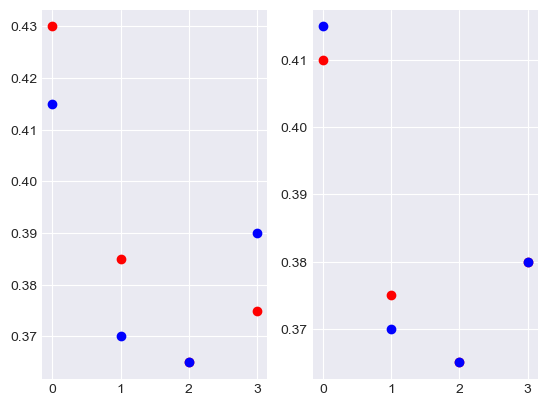

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(np.arange(len(pc_1_old)-1), inter_1_new, c='r')
ax[0].scatter(np.arange(len(pc_1_old)-1), inter_1_old, c='b')
ax[0].grid()
ax[1].scatter(np.arange(len(pc_1_old)-1), inter_2_old, c='r')
ax[1].scatter(np.arange(len(pc_1_old)-1), inter_2_new, c='b')
ax[1].grid()

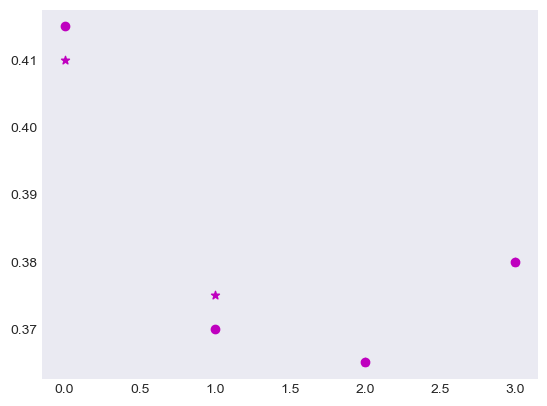

In [72]:
plt.scatter(np.arange(len(pc_1_old)-1), inter_2_old, marker='*', c='m')
plt.scatter(np.arange(len(pc_1_old)-1), inter_2_new, c='m')

## SLOPS

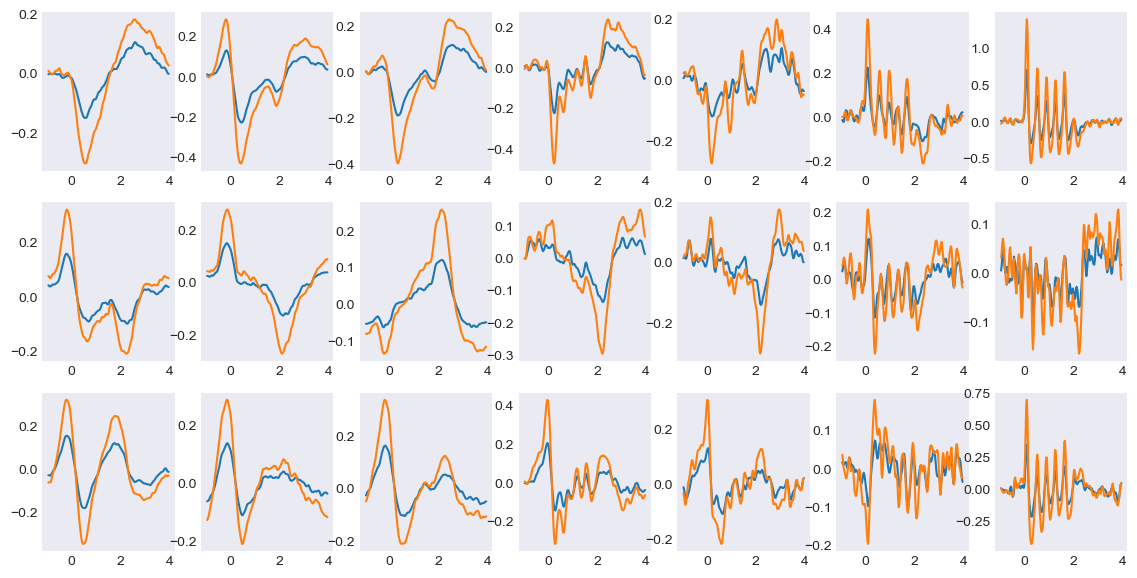

In [ ]:
# on ts
method_pca = 'concat'
ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0'])

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in ts.columns : 
        ts = ts.drop(columns = col)

ts = ts.values.reshape([7, 5, -1])
ts=np.concat([ts[None, :,  :, :int(ts.shape[2]/2)], ts[None, :, :,  int(ts.shape[2]/2):]], axis = 0)
fig, ax = plt.subplots(3, 7, figsize = (14, 7))

grad = np.zeros_like(ts) 
for pc in range(3) :
    for condi in range(ts.shape[0]):
        for freq in range(ts.shape[1]) : 
            grad[condi, freq, pc, :] = np.gradient(ts[condi, freq, pc, :])
            ax[pc][freq].plot(time_tfr, grad[:, freq, pc, :].mean(0), ls = '-')

In [178]:
# on weights of clf
band = 'high_gamma'
method_pca = 'concat'
data_aug_method = 'mean'
model_name = 'RandomForest'
time = time_tfr
from utils import cleandfdecodingTS

grad_list = []
for PC_use in [0, 2] : 

    df_final = pd.read_csv(OUT_PATH + f'/Decoding/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv') #_crp18_197_

    result = cleandfdecodingTS(df_final, len(time))
    w =result['weight']
    w_sh = result['weight_sh_mean']
    w_std = result['weight_sh_std']
    w = np.where(w > w_sh + 2*w_std, w, 0)

    grad = np.zeros_like(w) 
    for r in range(100) :
        grad[r,  :] = np.gradient(w[r, :])
    grad_list.append(grad)

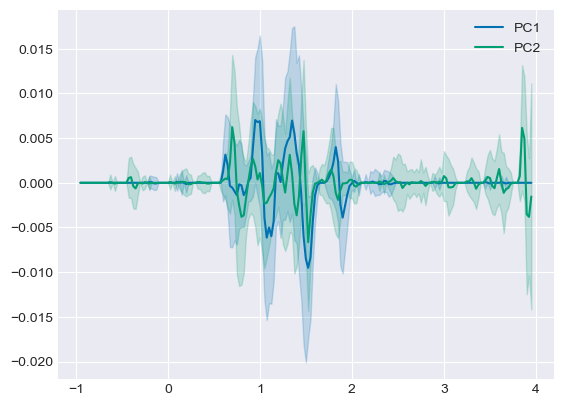

In [ ]:
plt.plot(time_tfr, grad_list[0].mean(0), label = 'PC1', c=col_pc[0])
plt.fill_between(time_tfr, grad_list[0].mean(0) - grad_list[0].std(0), grad_list[0].mean(0) + grad_list[0].std(0), color=col_pc[0], alpha = 0.2)
plt.plot(time_tfr, grad_list[1].mean(0), label = 'PC2', c=col_pc[2])
plt.fill_between(time_tfr, grad_list[1].mean(0) - grad_list[1].std(0), grad_list[1].mean(0) + grad_list[1].std(0), color=col_pc[2], alpha = 0.2)
plt.grid()

#plt.plot(time_tfr, w.mean(0), ls=':')
plt.legend()

## Delta check

In [64]:
band = 'high_gamma'
method_pca = 'concat'
grp_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_concat/grp_concat_compo_PCA5.csv').drop(columns = 'Unnamed: 0').query('freq == @band')
ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in ts.columns : 
        ts = ts.drop(columns = col)

    if col in grp_compo.columns :
        grp_compo = grp_compo.drop(columns = col)

compo = grp_compo.values
ts = ts.values
ts_pc=np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis = 0)


In [65]:
from utils import get_data_grp
data = get_data_grp(subj_included, 'tfr', (False, 0), return_subj=False, data_path=tfr_path)
delta_data=data[:, :, FREQ_BAND.index(band), :]
delta_data = np.concat([delta_data[0, :, :], delta_data[1, :, :]], axis=1)
delta_data_c = delta_data - delta_data.mean(1, keepdims=True)

In [84]:
# Tr
import pickle
import random
from utils import DataAugmentation
TFRtr_list = []

for subj in subj_included : 
    file = tfr_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        TFRtr = pickle.load(f)  

    info_file = tfr_path + f'/{subj}_info.json'
    with open(info_file) as f:
        info = json.load(f)
        events_index = np.array([int(i) for i in info['event_id']])

    id_ev1 = np.where(events_index == 1)[0]
    id_ev2 = np.where(events_index == 2)[0]

    id_test= [random.sample(list(id_ev1),1), random.sample(list(id_ev2),1)]
    id_ev1 = list(id_ev1)
    id_ev1.remove(id_test[0])
    id_ev1 = np.array(id_ev1)
    id_ev2 = list(id_ev2)
    id_ev2.remove(id_test[1])
    id_ev2 = np.array(id_ev2)

    # Augment the data
    TFRtr_augmented, _ = DataAugmentation(TFRtr[:, :, FREQ_BAND.index(band), :], [id_ev1, id_ev2], 'duplicat')
    TFRtr_list.append(TFRtr_augmented)


In [85]:
TFRtr= np.concat(TFRtr_list, axis = 1)
TFRtr = np.concat([TFRtr[:23, :, :], TFRtr[23:, :, :]], axis = 2)

In [86]:
for i in range(TFRtr.shape[0]) : 
    TFRtr[i, :, :] = TFRtr[i, :, :] - delta_data.mean(1, keepdims=True)

transform = np.zeros((TFRtr.shape[0], 5, TFRtr.shape[2]))
for pc in range(5) : 
    for i in range(TFRtr.shape[0]) : 
        transform[:,pc,:] = compo[pc, :] @ TFRtr[i, :, :] 

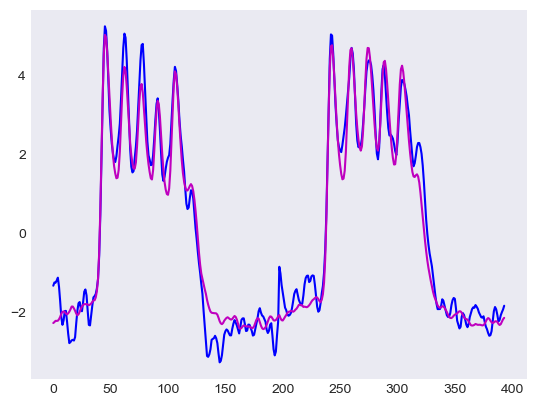

In [87]:
plt.plot(transform.mean(0)[0, :].T, c = 'b')
plt.plot(ts[0, :], c='m')

In [88]:
from sklearn.decomposition import PCA

pca = PCA(5)
transform1 = pca.fit_transform(delta_data.T)

weights = pca.components_
m = pca.mean_

weights.shape

for i in range(TFRtr.shape[0]) : 
    TFRtr[i, :, :] = TFRtr[i, :, :] #- m[:, None]

transform = np.zeros((TFRtr.shape[0], 5, TFRtr.shape[2]))
for pc in range(5) : 
    for i in range(TFRtr.shape[0]) : 
        transform[:,pc,:] = weights[pc, :] @ TFRtr[i, :, :] 


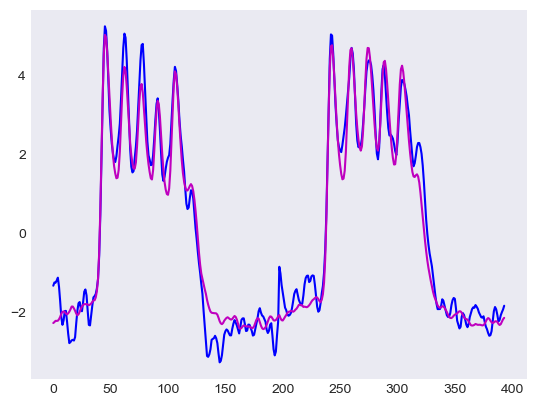

In [89]:
plt.plot(transform.mean(0)[0, :].T, c = 'b')
plt.plot(transform1[:, 0], c='m')